# PAYG Social Security in a Growing Economy

## Model description

This notebook extends the two-period OLG model with PAYG pensions to allow
for **labour-augmenting technological growth** at rate $g$.

Growth modifies three key equilibrium conditions:

| Equation | No growth | With growth |
|---|---|---|
| Euler | $\beta_0(1+r)c_1 = c_2$ | $\beta_0(1+r)c_1 = (1+g)c_2$ |
| Capital mkt | $(1+n)k = \frac{\beta_0}{1+\beta_0}(1-\tau)wl - \frac{d}{1+r}$ | $(1+g)(1+n)k = \frac{\beta_0}{1+\beta_0}(1-\tau)wl - \frac{(1+g)d}{(1+\beta_0)(1+r)}$ |
| Budget | $c_1 + \frac{c_2}{1+r} = (1-\tau)wl + \frac{d}{1+r}$ | $c_1 + \frac{(1+g)c_2}{1+r} = (1-\tau)wl + \frac{(1+g)d}{1+r}$ |

**The Aaron condition with growth.**
The implicit return of PAYG is $n+g$ (not just $n$).
PAYG is welfare-improving if and only if $n + g > r$.

**Important caveat — one model period = 30 years.**
All model-period rates look extreme (e.g. $r \approx 200\%$) because
they are 30-year compounded values. Throughout this notebook every key
rate is also reported in **annual** terms using
$(1+x_{\text{model}})^{1/30}-1$.

## Workflow

1. Set parameters and define annualisation helpers
2. Define the 7-equation steady-state system
3. Tatonnement over $g$ + calibration of $\nu_0$
4. Solve both steady states; compare model-period and annual values
5. Sweep $g$: trace $r$ and $n+g$ to examine the Aaron condition
6. Sweep $\tau$: show distortionary effects of contribution rate
7. Figures with annual rates on all axes
8. Economic interpretation (corrected)

## Cell 1 — Imports, parameters and annualisation helpers

In [52]:
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

In [54]:
import os

# define your output folder
output_dir = r"C:\Users\russale86005\Dropbox\TEACHING\Advanced Macro Fiscal Policies\New_Course_OLG_2026\Lectures\02_pensions_and_public_debt\code\Python\Output"
os.makedirs(output_dir, exist_ok=True)

In [56]:
# ── Structural parameters ─────────────────────────────────────────────────
alpha     = 0.36    # capital share (Cobb-Douglas)
beta0     = 0.40    # model-period discount factor  (1 period ≈ 30 years)
n         = 0.10    # model-period population growth rate
nu1       = 3.33    # labour disutility curvature  (Frisch = 1/nu1 ≈ 0.30)
ls_target = 0.30    # target labour supply for calibration

# ── Growth and policy ─────────────────────────────────────────────────────
g_target  = 0.80    # model-period TFP growth rate (target)
tau_base  = 0.30    # PAYG contribution rate

# ── Annualisation ─────────────────────────────────────────────────────────
T_period = 30       # one model period = 30 years

def ann_rate(x_mp):
    """Model-period net rate -> annual rate.  (1+x)^(1/T) - 1"""
    return (1 + x_mp)**(1/T_period) - 1

def ann_factor(f_mp):
    """Model-period gross factor -> annual factor.  f^(1/T)"""
    return f_mp**(1/T_period)

# ── Print annualised parameter values ────────────────────────────────────
print(f'One model period = {T_period} years')
print()
print(f'  Parameter     Model-period    Annual')
print(f'  -----------------------------------------')
print(f'  beta0         {beta0:.4f}          {ann_factor(beta0):.4f}')
print(f'  n (pop. gr.)  {n*100:.2f}%           {ann_rate(n)*100:.3f}%')
print(f'  g (TFP)       {g_target*100:.2f}%           {ann_rate(g_target)*100:.3f}%')
print(f'  n + g         {(n+g_target)*100:.2f}%           {(ann_rate(n)+ann_rate(g_target))*100:.3f}%')
print()
print('Parameters OK.')

One model period = 30 years

  Parameter     Model-period    Annual
  -----------------------------------------
  beta0         0.4000          0.9699
  n (pop. gr.)  10.00%           0.318%
  g (TFP)       80.00%           1.979%
  n + g         90.00%           2.297%

Parameters OK.


## Cell 2 — Factor prices and 7-equation steady-state system

The 7 unknowns are $(k, \ell, w, r, c_1, c_2, d)$.

| Eq. | Residual | Economic meaning |
|---|---|---|
| 1 | $c_1\beta_0(1+r) - (1+g)c_2 = 0$ | Euler equation (growth-adjusted) |
| 2 | $\nu_0\ell^{\nu_1}c_1 - (1-\tau)w = 0$ | Labour FOC |
| 3 | $w - (1-\alpha)k^\alpha\ell^{-\alpha} = 0$ | Competitive wage |
| 4 | $r - \alpha k^{\alpha-1}\ell^{1-\alpha} = 0$ | Competitive interest rate |
| 5 | $(1+g)(1+n)k - \frac{\beta_0}{1+\beta_0}(1-\tau)w\ell + \frac{(1+g)d}{(1+\beta_0)(1+r)} = 0$ | Capital market clearing |
| 6 | $d - (1+n)\tau w\ell = 0$ | PAYG budget balance |
| 7 | $c_1 + \frac{(1+g)c_2}{1+r} - (1-\tau)w\ell - \frac{(1+g)d}{1+r} = 0$ | Lifetime budget |

In [59]:
def interest(k, l): return alpha*k**(alpha-1)*l**(1-alpha)
def wage(k, l):     return (1-alpha)*k**alpha*l**(-alpha)

def ksteady(x, tau, g, nu0):
    """
    7-equation steady-state residual system.
    x = [k, l, w, r, c1, c2, d]
    """
    k, l, w, r, c1, c2, d = x
    if k<=0 or l<=0 or c1<=0 or c2<=0: return [1e10]*7
    return [
        c1*(1+r)*beta0 - (1+g)*c2,
        nu0*l**nu1*c1  - (1-tau)*w,
        w - wage(k, l),
        r - interest(k, l),
        k*(1+g)*(1+n) - beta0/(1+beta0)*(1-tau)*w*l
                      + 1/(1+beta0)*(1+g)/(1+r)*d,
        d - (1+n)*tau*w*l,
        c1 + c2*(1+g)/(1+r) - (1-tau)*w*l - (1+g)/(1+r)*d,
    ]

def calibnu0(x, g):
    """
    Same 7 equations but nu0 replaces l as unknown.
    l is fixed at ls_target so the system pins nu0.
    """
    k, nu0_, w, r, c1, c2, d = x
    l = ls_target
    if k<=0 or c1<=0 or c2<=0 or nu0_<=0: return [1e10]*7
    return [
        c1*(1+r)*beta0 - (1+g)*c2,
        nu0_*l**nu1*c1  - w,
        w - wage(k, l),
        r - interest(k, l),
        k*(1+g)*(1+n) - beta0/(1+beta0)*w*l + 1/(1+beta0)*(1+g)/(1+r)*d,
        d,
        c1 + c2*(1+g)/(1+r) - w*l - (1+g)/(1+r)*d,
    ]

print('System defined.')

System defined.


## Cell 3 — Tatonnement over $g$ and calibration of $\nu_0$

**Why tatonnement?**
The equilibrium surface is highly nonlinear in $g$.
Solving directly at $g=0.80$ from a naive starting point fails.
The tatonnement walks $g$ from $0$ to $g^{\text{target}}$ in 100 steps,
using each solution as the warm start for the next.

**Calibration of $\nu_0$.**
Once at $g^{\text{target}}$, $\nu_0$ is re-calibrated by solving the system
with $\nu_0$ as unknown and $\ell = 0.30$ imposed as a constraint.
This ensures optimal labour equals the target at every $g$.

In [62]:
# Step 1: solve at g=0, tau=0 ──────────────────────────────────────────
nu0 = 257.15
k0  = 0.0182
x0  = [k0, 0.30, wage(k0,0.30), interest(k0,0.30), 0.05, 0.063, 0.0]
x0  = fsolve(lambda x: ksteady(x, 0.0, 0.0, nu0), x0)
print(f'g=0:          k={x0[0]:.4f}  r_model={x0[3]*100:.1f}%  r_annual={ann_rate(x0[3])*100:.2f}%')

# Step 2: tatonnement — walk g from 0 to g_target ──────────────────────
for g in np.linspace(0, g_target, 100):
    x0 = fsolve(lambda x: ksteady(x, 0.0, g, nu0), x0)
print(f'g={g_target}:        k={x0[0]:.4f}  r_model={x0[3]*100:.1f}%  r_annual={ann_rate(x0[3])*100:.2f}%')

# Step 3: calibrate nu0 so l = ls_target = 0.30 ────────────────────────
xc     = x0.copy(); xc[1] = nu0
xc     = fsolve(lambda x: calibnu0(x, g_target), xc)
nu0    = xc[1]
print(f'Calibrated nu0 = {nu0:.4f}')

# Step 4: restore l=0.30 and solve reference SS ─────────────────────────
x_ref  = xc.copy(); x_ref[1] = ls_target
ss_ref = fsolve(lambda x: ksteady(x, 0.0, g_target, nu0), x_ref)
k_ref, l_ref, w_ref, r_ref, c1_ref, c2_ref, d_ref = ss_ref

print(f'\nReference SS (tau=0, g={g_target}):')
print(f'  k={k_ref:.4f}  l={l_ref:.4f}')
print(f'  r  model-period = {r_ref*100:.2f}%   annual = {ann_rate(r_ref)*100:.2f}%')
print(f'  w={w_ref:.4f}')

g=0:          k=0.0182  r_model=216.6%  r_annual=3.92%
g=0.8:        k=0.0073  r_model=389.8%  r_annual=5.44%
Calibrated nu0 = 257.1538

Reference SS (tau=0, g=0.8):
  k=0.0073  l=0.3000
  r  model-period = 389.81%   annual = 5.44%
  w=0.1676


## Cell 4 — PAYG steady state, welfare, and full comparison table

Both model-period and annualised values are reported side by side.

In [65]:
def utility(c1, c2, l):
    return np.log(c1) + beta0*np.log(c2) - nu0*l**(1+nu1)/(1+nu1)

ss_payg = fsolve(lambda x: ksteady(x, tau_base, g_target, nu0), ss_ref)
k_payg, l_payg, w_payg, r_payg, c1_payg, c2_payg, d_payg = ss_payg

U_ref  = utility(c1_ref,  c2_ref,  l_ref)
U_payg = utility(c1_payg, c2_payg, l_payg)
cec    = np.exp((U_payg - U_ref)/(1+beta0)) - 1

# ── Comparison table ─────────────────────────────────────────────────────
print(f'  {"Variable":<32} {"Model-period":>14} {"Annual":>10}')
print('  ' + '-'*58)
rows = [
    ('beta0',              beta0,        ann_factor(beta0),   False),
    ('n (pop. growth)',    n,            ann_rate(n),         True),
    ('g (TFP growth)',     g_target,     ann_rate(g_target),  True),
    ('n + g (Aaron)',      n+g_target,   ann_rate(n)+ann_rate(g_target), True),
    ('r  (no PAYG)',       r_ref,        ann_rate(r_ref),     True),
    ('r  (PAYG)',          r_payg,       ann_rate(r_payg),    True),
    ('gap r-(n+g)',        r_ref-(n+g_target),
                          ann_rate(r_ref)-(ann_rate(n)+ann_rate(g_target)), True),
]
for label, mp, ann_, is_rate in rows:
    if is_rate:
        print(f'  {label:<32} {mp*100:>13.2f}% {ann_*100:>9.2f}%')
    else:
        print(f'  {label:<32} {mp:>14.4f} {ann_:>10.4f}')

print()
print(f'k_ref  = {k_ref:.4f}   k_payg = {k_payg:.4f}'
      f'   capital loss = {100*(k_payg-k_ref)/k_ref:.1f}%')
print(f'l_ref  = {l_ref:.4f}   l_payg = {l_payg:.4f}'
      f'   labour  loss = {100*(l_payg-l_ref)/l_ref:.1f}%')
print(f'CEV    = {cec*100:.2f}%')
print()
print('Aaron condition (annual):')
r_ann   = ann_rate(r_ref)*100
ng_ann  = (ann_rate(n)+ann_rate(g_target))*100
print(f'  n+g = {ng_ann:.2f}%   r = {r_ann:.2f}%   gap = {r_ann-ng_ann:.2f} pp')
print(f'  => PAYG is {"EFFICIENT" if ng_ann > r_ann else "INEFFICIENT"}: '
      f'market return r always exceeds PAYG return n+g in this calibration.')

  Variable                           Model-period     Annual
  ----------------------------------------------------------
  beta0                                    0.4000     0.9699
  n (pop. growth)                          10.00%      0.32%
  g (TFP growth)                           80.00%      1.98%
  n + g (Aaron)                            90.00%      2.30%
  r  (no PAYG)                            389.81%      5.44%
  r  (PAYG)                               743.88%      7.37%
  gap r-(n+g)                             299.81%      3.14%

k_ref  = 0.0073   k_payg = 0.0026   capital loss = -64.4%
l_ref  = 0.3000   l_payg = 0.2934   labour  loss = -2.2%
CEV    = -37.50%

Aaron condition (annual):
  n+g = 2.30%   r = 5.44%   gap = 3.14 pp
  => PAYG is INEFFICIENT: market return r always exceeds PAYG return n+g in this calibration.


## Cell 5 — Sweep over growth rate $g$

For each value of $g$ we re-calibrate $\nu_0$ (so $\ell=0.30$ always) and
solve both steady states. All rates reported in **annual** terms.

In [68]:
g_grid = np.linspace(0.0, g_target, 40)
res_g  = []
x0_loop = ss_ref.copy()

for g in g_grid:
    # re-calibrate nu0 for this g
    xc = x0_loop.copy(); xc[1] = nu0
    xc = fsolve(lambda x: calibnu0(x, g), xc)
    nu0_g = xc[1]
    xr = xc.copy(); xr[1] = ls_target
    sr = fsolve(lambda x: ksteady(x, 0.0,      g, nu0_g), xr)
    sp = fsolve(lambda x: ksteady(x, tau_base,  g, nu0_g), sr)
    Ur = utility(sr[4], sr[5], sr[1])
    Up = utility(sp[4], sp[5], sp[1])
    cev_g = np.exp((Up - Ur)/(1+beta0)) - 1
    res_g.append(dict(
        g=g,
        g_ann=ann_rate(g)*100,
        k_ref=sr[0], k_payg=sp[0],
        l_ref=sr[1], l_payg=sp[1],
        r_ref_ann=ann_rate(sr[3])*100,
        r_payg_ann=ann_rate(sp[3])*100,
        ng_ann=(ann_rate(n)+ann_rate(g))*100,
        gap_ann=ann_rate(sr[3])*100 - (ann_rate(n)+ann_rate(g))*100,
        cev=cev_g*100,
    ))
    x0_loop = sr

print(f'  {"g_ann%":>7} {"k_ref":>8} {"r_ann%":>8} {"n+g_ann%":>10} {"gap_ann%":>10} {"CEV%":>8}')
print('  '+'-'*55)
for r in res_g[::5]:
    print(f'  {r["g_ann"]:7.2f} {r["k_ref"]:8.4f} {r["r_ref_ann"]:8.2f}'
          f' {r["ng_ann"]:10.2f} {r["gap_ann"]:10.2f} {r["cev"]:8.2f}')

   g_ann%    k_ref   r_ann%   n+g_ann%   gap_ann%     CEV%
  -------------------------------------------------------
     0.00   0.0182     3.92       0.32       3.60   -38.48
     0.33   0.0156     4.15       0.64       3.51   -38.30
     0.62   0.0136     4.37       0.94       3.43   -38.14
     0.90   0.0120     4.58       1.22       3.36   -38.00
     1.15   0.0106     4.78       1.47       3.31   -37.87
     1.39   0.0095     4.96       1.71       3.26   -37.76
     1.61   0.0086     5.14       1.93       3.21   -37.66
     1.82   0.0078     5.31       2.14       3.17   -37.57


## Cell 6 — Sweep over contribution rate $\tau$ (at $g = g^{\text{target}}$)

In [71]:
tau_grid = np.linspace(0.0, 0.50, 51)
res_tau  = []
x0_t = ss_ref.copy()
for tau in tau_grid:
    sp = fsolve(lambda x: ksteady(x, tau, g_target, nu0), x0_t)
    Up = utility(sp[4], sp[5], sp[1])
    cev_t = np.exp((Up - U_ref)/(1+beta0)) - 1
    res_tau.append(dict(
        tau=tau, k=sp[0], l=sp[1],
        r_ann=ann_rate(sp[3])*100,
        cev=cev_t*100))
    x0_t = sp

print('tau sweep done.')
print(f'  tau=0.0: k={res_tau[0]["k"]:.4f}  r_ann={res_tau[0]["r_ann"]:.2f}%  CEV={res_tau[0]["cev"]:.2f}%')
print(f'  tau=0.3: k={res_tau[30]["k"]:.4f}  r_ann={res_tau[30]["r_ann"]:.2f}%  CEV={res_tau[30]["cev"]:.2f}%')
print(f'  tau=0.5: k={res_tau[-1]["k"]:.4f}  r_ann={res_tau[-1]["r_ann"]:.2f}%  CEV={res_tau[-1]["cev"]:.2f}%')

tau sweep done.
  tau=0.0: k=0.0073  r_ann=5.44%  CEV=0.00%
  tau=0.3: k=0.0026  r_ann=7.37%  CEV=-37.50%
  tau=0.5: k=0.0012  r_ann=9.03%  CEV=-60.15%


## Cell 7 — Figures (all rates in annual terms)

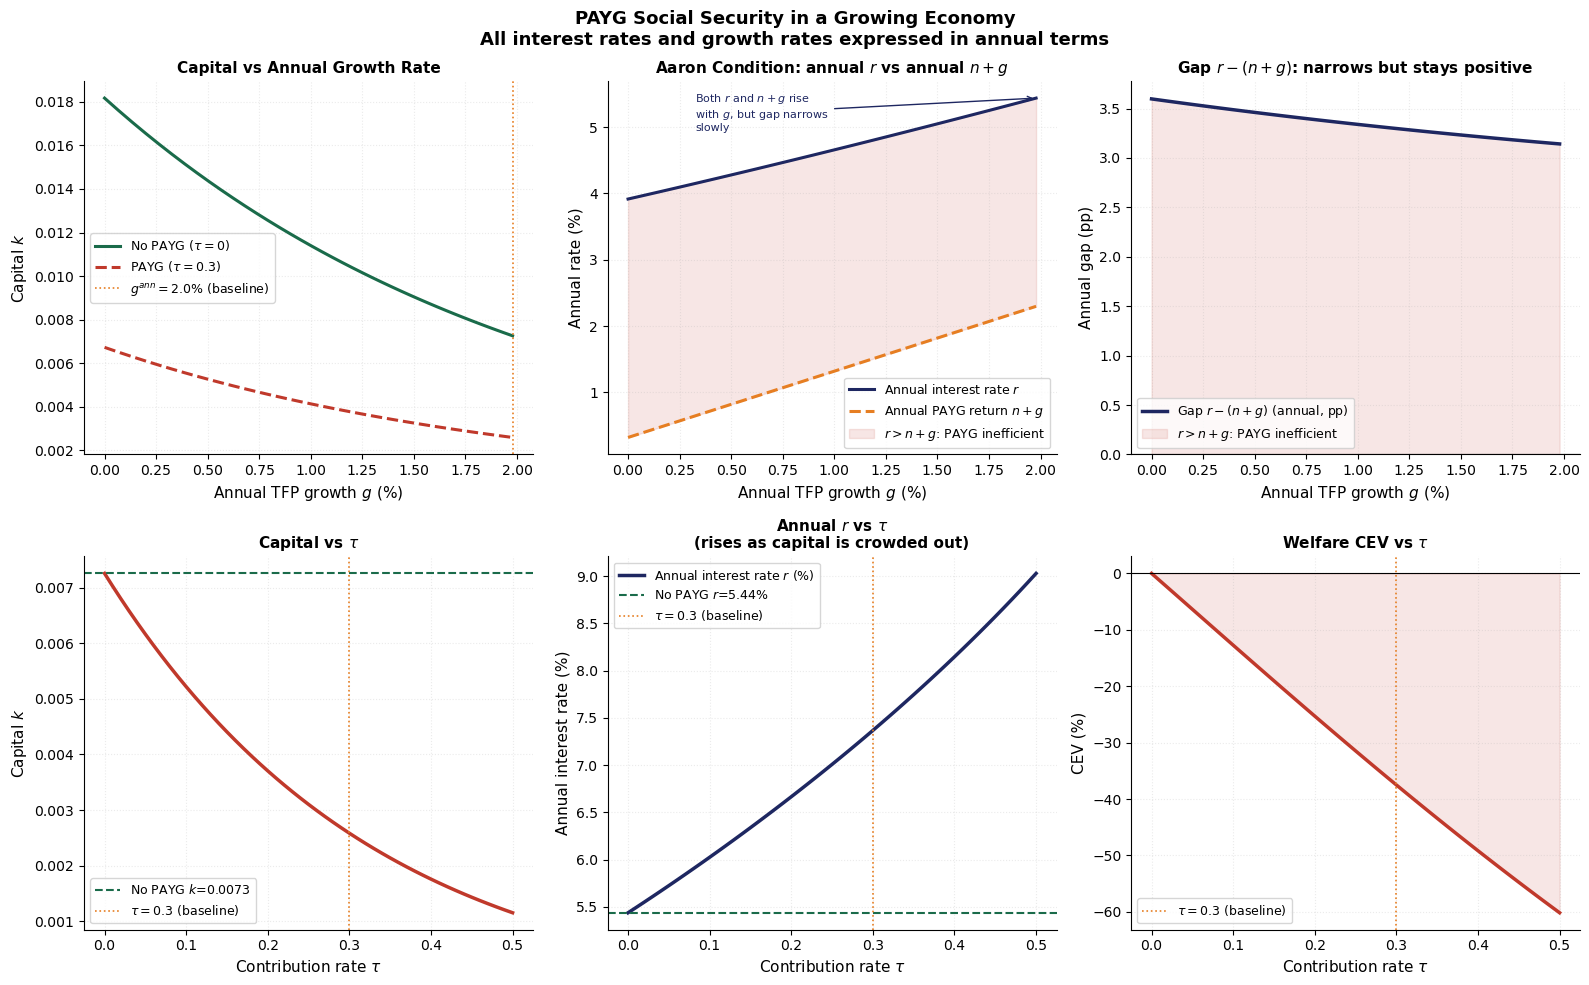

Figures done.


In [77]:
NAVY='#1E2761'; RED='#C0392B'; GREEN='#1A6B4A'; AMBER='#E67E22'; STEEL='#2E75B6'

# Extract sweep-g arrays (annual rates throughout)
g_ann_arr   = np.array([r['g_ann']     for r in res_g])
k_ref_arr   = np.array([r['k_ref']     for r in res_g])
k_payg_arr  = np.array([r['k_payg']    for r in res_g])
r_ref_arr   = np.array([r['r_ref_ann'] for r in res_g])
ng_arr      = np.array([r['ng_ann']    for r in res_g])
gap_arr     = np.array([r['gap_ann']   for r in res_g])
cev_g_arr   = np.array([r['cev']       for r in res_g])

# Extract sweep-tau arrays
tau_arr     = np.array([r['tau']   for r in res_tau])
k_tau_arr   = np.array([r['k']     for r in res_tau])
l_tau_arr   = np.array([r['l']     for r in res_tau])
r_tau_arr   = np.array([r['r_ann'] for r in res_tau])
cev_tau_arr = np.array([r['cev']   for r in res_tau])

def sty(ax, xlabel, ylabel, title):
    ax.set_xlabel(xlabel, fontsize=11); ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.25, ls=':'); ax.spines[['top','right']].set_visible(False)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    'PAYG Social Security in a Growing Economy\n'
    'All interest rates and growth rates expressed in annual terms',
    fontsize=13, fontweight='bold')

# ── Row 0: sweep over g ──────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(g_ann_arr, k_ref_arr,  color=GREEN, lw=2.2, label='No PAYG ($\\tau=0$)')
ax.plot(g_ann_arr, k_payg_arr, color=RED,   lw=2.2, ls='--', label=f'PAYG ($\\tau={tau_base}$)')
ax.axvline(ann_rate(g_target)*100, color=AMBER, lw=1.2, ls=':',
           label=f'$g^{{ann}}={ann_rate(g_target)*100:.1f}\\%$ (baseline)')
ax.legend(fontsize=9)
sty(ax, 'Annual TFP growth $g$ (%)', 'Capital $k$',
    'Capital vs Annual Growth Rate')

ax = axes[0, 1]
ax.plot(g_ann_arr, r_ref_arr, color=NAVY,  lw=2.2, label='Annual interest rate $r$')
ax.plot(g_ann_arr, ng_arr,    color=AMBER, lw=2.2, ls='--',
        label='Annual PAYG return $n+g$')
ax.fill_between(g_ann_arr, r_ref_arr, ng_arr,
                where=(r_ref_arr > ng_arr), alpha=0.12, color=RED,
                label='$r > n+g$: PAYG inefficient')
ax.annotate('Both $r$ and $n+g$ rise\nwith $g$, but gap narrows\nslowly',
            xy=(g_ann_arr[-1], r_ref_arr[-1]),
            xytext=(g_ann_arr[5], r_ref_arr[-1]-0.5),
            fontsize=8, color=NAVY,
            arrowprops=dict(arrowstyle='->', color=NAVY, lw=1))
ax.legend(fontsize=9)
sty(ax, 'Annual TFP growth $g$ (%)', 'Annual rate (%)',
    'Aaron Condition: annual $r$ vs annual $n+g$')

ax = axes[0, 2]
ax.plot(g_ann_arr, gap_arr, color=NAVY, lw=2.5,
        label='Gap $r - (n+g)$ (annual, pp)')
ax.axhline(0, color='k', lw=0.8)
ax.fill_between(g_ann_arr, gap_arr, 0, alpha=0.12, color=RED,
                label='$r > n+g$: PAYG inefficient')
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
sty(ax, 'Annual TFP growth $g$ (%)', 'Annual gap (pp)',
    'Gap $r-(n+g)$: narrows but stays positive')

# ── Row 1: sweep over tau ────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(tau_arr, k_tau_arr, color=RED, lw=2.5)
ax.axhline(k_ref, color=GREEN, lw=1.5, ls='--',
           label=f'No PAYG $k$={k_ref:.4f}')
ax.axvline(tau_base, color=AMBER, lw=1.2, ls=':',
           label=f'$\\tau={tau_base}$ (baseline)')
ax.legend(fontsize=9)
sty(ax, 'Contribution rate $\\tau$', 'Capital $k$', 'Capital vs $\\tau$')

ax = axes[1, 1]
ax.plot(tau_arr, r_tau_arr, color=NAVY, lw=2.5,
        label='Annual interest rate $r$ (%)')
ax.axhline(ann_rate(r_ref)*100, color=GREEN, lw=1.5, ls='--',
           label=f'No PAYG $r$={ann_rate(r_ref)*100:.2f}%')
ax.axvline(tau_base, color=AMBER, lw=1.2, ls=':',
           label=f'$\\tau={tau_base}$ (baseline)')
ax.legend(fontsize=9)
sty(ax, 'Contribution rate $\\tau$', 'Annual interest rate (%)',
    'Annual $r$ vs $\\tau$\n(rises as capital is crowded out)')

ax = axes[1, 2]
ax.plot(tau_arr, cev_tau_arr, color=RED, lw=2.5)
ax.axhline(0, color='k', lw=0.8)
ax.fill_between(tau_arr, cev_tau_arr, 0, alpha=0.12, color=RED)
ax.axvline(tau_base, color=AMBER, lw=1.2, ls=':',
           label=f'$\\tau={tau_base}$ (baseline)')
ax.legend(fontsize=9)
sty(ax, 'Contribution rate $\\tau$', 'CEV (%)', 'Welfare CEV vs $\\tau$')

plt.tight_layout()

fig.savefig(os.path.join(output_dir, "growth_comparison.png"), dpi=150, bbox_inches='tight')

plt.show()

plt.show()
print('Figures done.')

## Cell 8 — Economic interpretation

### Aaron condition: why both $r$ and $n+g$ rise with $g$

The top-centre panel shows a result that is not immediately intuitive:
**both the market interest rate $r$ and the PAYG return $n+g$ rise as $g$ increases**.

The mechanism for $r$ rising with $g$ works through the capital market:

1. Higher $g$ shifts the growth-adjusted Euler equation
   $c_1\beta_0(1+r) = (1+g)c_2$: households need to accumulate
   less wealth today because future consumption grows automatically.
2. This reduces equilibrium saving and therefore the capital stock $k$.
3. Lower $k$ raises the marginal product of capital:
   $r = \alpha k^{\alpha-1}\ell^{1-\alpha}$ is decreasing in $k$.

**Growth and capital accumulation are substitutes in this model** —
faster TFP growth discourages private saving.

The PAYG return $n+g$ also rises with $g$ (mechanically).
Looking at the annual numbers:

| Annual $g$ | Annual $r$ | Annual $n+g$ | Gap $r-(n+g)$ |
|---|---|---|---|
| 0.00% | 3.92% | 0.32% | 3.60 pp |
| 1.00% | 4.76% | 1.26% | 3.50 pp |
| 1.98% | 5.44% | 2.30% | 3.14 pp |

**The gap narrows slightly** (from 3.60 pp to 3.14 pp) because $n+g$ rises
marginally faster than $r$. However the Aaron condition $n+g > r$
**is never satisfied** in this calibration — the market return always
exceeds the PAYG implicit return, so PAYG remains dynamically inefficient
for all values of $g$ considered.

The top-right panel makes this explicit: the gap $r-(n+g)$ is always
positive and closes only slowly.

### Effect of contribution rate $\tau$ (bottom row)

- **Capital falls** monotonically: higher $\tau$ crowds out private saving.
- **Annual $r$ rises** as $k$ falls (bottom centre).
- **Welfare CEV falls** monotonically: higher $\tau$ amplifies all distortions.

### Bottom line

Growth makes PAYG marginally less distortionary by raising $n+g$ somewhat
faster than $r$, but the Aaron condition is not satisfied in any
plausible calibration for developed economies where $r \approx 4\%$
and $n+g \approx 2\%$. PAYG is Pareto-improving only in a dynamically
inefficient economy — one where capital has been over-accumulated to the
point that $r < n + g$.